<a href="https://colab.research.google.com/github/Lzyrus40/Pytorch/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **WorkFIow**

0. Import important libraries
1. Get dataset ready (turn into tensor,and batches)
2. Build NeuralNetwork Model for classification
3. Pick aloss function and optimizer
4. build a training loop
5. evaluate your model
6. improving ourmodel
7. save the model

# **0. Import important libraries**

In [96]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import matplotlib.pyplot as plt

# **1. Get dataset ready (turn into tensor,and batches)**

In [97]:
train_dataset = datasets.FashionMNIST(root="dataset",train=True, transform=transforms.ToTensor(),download=True)
test_dataset = datasets.FashionMNIST(root="dataset",train=False, transform=transforms.ToTensor(),download=True)

In [98]:
train_dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: dataset
    Split: Train
    StandardTransform
Transform: ToTensor()

In [99]:
test_dataset

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: dataset
    Split: Test
    StandardTransform
Transform: ToTensor()

**Converting Data to Batches**

In [100]:
batch_size = 64
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [101]:
len(train_loader)
# 60000 / 64 == 937.5


938

In [102]:
len(test_loader)
# 10000 / 64 == 156.25

157

# **2. Build NeuralNetwork Model for classification**

In [103]:
class NeuralNetwork(nn.Module):
  def __init__(self,n_dim,n_hidden1,n_hidden2,out_dim):
    super().__init__()
    self.layer1 = nn.Sequential(
        nn.Linear(n_dim,n_hidden1),
        nn.ReLU(True),
    )
    self.layer2 = nn.Sequential(
        nn.Linear(n_hidden1,n_hidden2),
        nn.ReLU(True),
    )
    self.layer3 = nn.Sequential(
        nn.Linear(n_hidden2,out_dim),
        nn.ReLU(True),
    )

  def forward (self,x):
    a=self.layer1(x)
    b=self.layer2(a)
    c=self.layer3(b)
    return c

In [104]:
in_dim = 28*28 # 784
n_hidden1 = 300
n_hidden2 = 100
out_dim = 10


In [105]:
model = NeuralNetwork(in_dim,n_hidden1,n_hidden2,out_dim)

In [106]:
model

NeuralNetwork(
  (layer1): Sequential(
    (0): Linear(in_features=784, out_features=300, bias=True)
    (1): ReLU(inplace=True)
  )
  (layer2): Sequential(
    (0): Linear(in_features=300, out_features=100, bias=True)
    (1): ReLU(inplace=True)
  )
  (layer3): Sequential(
    (0): Linear(in_features=100, out_features=10, bias=True)
    (1): ReLU(inplace=True)
  )
)

In [107]:
model.state_dict() # show all baises and weights

OrderedDict([('layer1.0.weight',
              tensor([[-0.0181, -0.0205, -0.0113,  ..., -0.0149,  0.0037, -0.0189],
                      [-0.0279,  0.0171, -0.0310,  ..., -0.0241,  0.0133, -0.0346],
                      [-0.0322, -0.0305, -0.0016,  ...,  0.0311, -0.0337, -0.0247],
                      ...,
                      [-0.0258, -0.0289,  0.0107,  ..., -0.0222, -0.0045,  0.0197],
                      [ 0.0091, -0.0122,  0.0016,  ..., -0.0111,  0.0278, -0.0340],
                      [-0.0143,  0.0051,  0.0335,  ...,  0.0068,  0.0158, -0.0324]])),
             ('layer1.0.bias',
              tensor([-0.0319,  0.0073, -0.0061, -0.0239,  0.0130,  0.0231, -0.0094, -0.0295,
                      -0.0145,  0.0139, -0.0096, -0.0192,  0.0048, -0.0106,  0.0101,  0.0181,
                       0.0342,  0.0229,  0.0131,  0.0179,  0.0161, -0.0345, -0.0319, -0.0229,
                       0.0128, -0.0214,  0.0206, -0.0010,  0.0357, -0.0349,  0.0025,  0.0179,
                      -0.0

In [108]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [109]:
model=model.to(device)

# **3. Pick aloss function and optimizer**

In [110]:
learning_rate = 1e-3

In [111]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

# **4. build a training loop**

In [112]:
num_epochs = 10

In [113]:
for epoch in range(num_epochs):
  print('*'*10)
  print(f'Epoch {epoch+1}')
  running_loss = 0.0
  running_acc = 0.0
  for i,data in enumerate(train_loader,1):
    img,label = data
    img = img.view(img.size(0),-1)
    img = img.to(device)
    label = label.to(device)
    out = model(img)
    loss = criterion(out,label)
    running_loss += loss.item()
    _,pred = torch.max(out,1)
    running_acc += (pred == label).float().mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if i%300 == 0:
      print(f'epoch {epoch+1}/{num_epochs}] loss: {running_loss/i:.6f} acc: {running_acc/i:.6f}')
  print(f'Finish : {epoch + 1} epoch , Loss : {running_loss/i:.6f} Acc: {running_acc/i:.6f}')

**********
Epoch 1
epoch 1/10] loss: 1.359078 acc: 0.583698
epoch 1/10] loss: 1.270019 acc: 0.611484
epoch 1/10] loss: 1.234572 acc: 0.622222
Finish : 1 epoch , Loss : 1.232762 Acc: 0.622784
**********
Epoch 2
epoch 2/10] loss: 1.136000 acc: 0.649323
epoch 2/10] loss: 1.138199 acc: 0.650547
epoch 2/10] loss: 1.124071 acc: 0.657031
Finish : 2 epoch , Loss : 1.118861 Acc: 0.659282
**********
Epoch 3
epoch 3/10] loss: 0.954154 acc: 0.729531
epoch 3/10] loss: 0.954027 acc: 0.728724
epoch 3/10] loss: 0.952204 acc: 0.728767
Finish : 3 epoch , Loss : 0.952297 Acc: 0.728928
**********
Epoch 4
epoch 4/10] loss: 0.929103 acc: 0.735208
epoch 4/10] loss: 0.922916 acc: 0.735104
epoch 4/10] loss: 0.922310 acc: 0.736892
Finish : 4 epoch , Loss : 0.920752 Acc: 0.737224
**********
Epoch 5
epoch 5/10] loss: 0.902653 acc: 0.740937
epoch 5/10] loss: 0.903423 acc: 0.741589
epoch 5/10] loss: 0.904733 acc: 0.741042
Finish : 5 epoch , Loss : 0.904589 Acc: 0.740955
**********
Epoch 6
epoch 6/10] loss: 0.885798

# **5. evaluate your model**

In [114]:
model.eval()
eval_loss = 0.
eval_acc = 0.
for data in test_loader:
  img,label = data
  img = img.view(img.size(0),-1)
  img = img.to(device)
  label = label.to(device)
  with torch.no_grad():
    out = model(img)
    loss = criterion(out,label)
    eval_loss += loss.item()
    _,pred = torch.max(out,1)
    eval_acc += (pred == label).float().mean()
print(f'Test Loss : {eval_loss/len(test_loader)}, Acc : {eval_acc/len(test_loader)}')

Test Loss : 0.9232709874772722, Acc : 0.7397491931915283


# **Visulize**

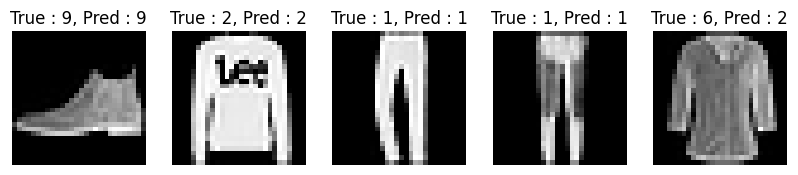

In [117]:
images, labels = next(iter(test_loader))
images = images.view(images.size(0), -1).to(device)
out = model(images)
_,pred = torch.max(out,1)
fig ,ax = plt.subplots(1,5,figsize=(10,5))
for i in range(5):
  ax[i].imshow(images[i].reshape(28,28).cpu(),cmap ='gray')
  ax[i].set_title(f'True : {labels[i].item()}, Pred : {pred[i].item()}')
  ax[i].axis('off')
plt.show()

# **6. improving ourmodel**

1. num_epochs
2. learning_rate
3. change optimizers (Adms, SGD etc)
4. change no of hidden neurons
5. increase or decrease the no of layers

# **7. save the model**

In [ ]:
torch.save(model.state_dict(),'./Model.pth')